
<a href="https://colab.research.google.com/github/CienciaDatosUdea/002_EstudiantesAprendizajeEstadistico/blob/main/semestre2026-1/Laboratorios/Laboratorio_01_pinguinos_v2_IA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>




LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


# FASE 1 — Enfoque clásico

## Parte A — Observación inicial

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Cargar dataset
df = sns.load_dataset("penguins")
print(f"Dataset cargado: {df.shape}")
df.head()

Dataset cargado: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [19]:
# 1) ¿Cuántas filas y columnas?
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"\nColumnas: {list(df.columns)}")

# 2) Variables numéricas y categóricas
print(f"\nVariables numéricas: {df.select_dtypes(include='number').columns.tolist()}")
print(f"Variables categóricas: {df.select_dtypes(include=['object', 'category']).columns.tolist()}")

# 3) Valores faltantes por columna
print("\nValores faltantes:")
missing = df.isna().sum()
for col in df.columns:
    if missing[col] > 0:
        print(f"  {col}: {missing[col]} ({missing[col]/len(df)*100:.1f}%)")
print(f"  Total columnas con faltantes: {(missing > 0).sum()}")

# 4) Filas duplicadas
n_dup = df.duplicated().sum()
print(f"\nFilas duplicadas: {n_dup}")

# 5) Variables con baja cardinalidad
print("\nCardinalidad por variable:")
for col in df.columns:
    nu = df[col].nunique()
    print(f"  {col}: {nu} valores únicos {'← baja cardinalidad' if nu <= 10 else ''}")

Filas: 344
Columnas: 7

Columnas: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Variables numéricas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Variables categóricas: ['species', 'island', 'sex']

Valores faltantes:
  bill_length_mm: 2 (0.6%)
  bill_depth_mm: 2 (0.6%)
  flipper_length_mm: 2 (0.6%)
  body_mass_g: 2 (0.6%)
  sex: 11 (3.2%)
  Total columnas con faltantes: 5

Filas duplicadas: 0

Cardinalidad por variable:
  species: 3 valores únicos ← baja cardinalidad
  island: 3 valores únicos ← baja cardinalidad
  bill_length_mm: 164 valores únicos 
  bill_depth_mm: 80 valores únicos 
  flipper_length_mm: 55 valores únicos 
  body_mass_g: 94 valores únicos 
  sex: 2 valores únicos ← baja cardinalidad


C:\Users\jhjurad\AppData\Local\Temp\ipykernel_16248\3386092428.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"Variables categóricas: {df.select_dtypes(include=['object', 'category']).columns.tolist()}")


## Parte B — Descripción

In [20]:
# 6) Resumen de variables numéricas
num_cols = df.select_dtypes(include="number").columns.tolist()
print("=== Resumen variables numéricas ===\n")
for c in num_cols:
    s = df[c].dropna()
    print(f"{c}:")
    print(f"  Media: {s.mean():.2f} | Mediana: {s.median():.2f}")
    print(f"  Desv. estándar: {s.std():.2f}")
    print(f"  Rango intercuartílico (IQR): {s.quantile(0.75) - s.quantile(0.25):.2f}")
    print(f"  Min: {s.min():.2f} | Max: {s.max():.2f}")
    print()

=== Resumen variables numéricas ===

bill_length_mm:
  Media: 43.92 | Mediana: 44.45
  Desv. estándar: 5.46
  Rango intercuartílico (IQR): 9.27
  Min: 32.10 | Max: 59.60

bill_depth_mm:
  Media: 17.15 | Mediana: 17.30
  Desv. estándar: 1.97
  Rango intercuartílico (IQR): 3.10
  Min: 13.10 | Max: 21.50

flipper_length_mm:
  Media: 200.92 | Mediana: 197.00
  Desv. estándar: 14.06
  Rango intercuartílico (IQR): 23.00
  Min: 172.00 | Max: 231.00

body_mass_g:
  Media: 4201.75 | Mediana: 4050.00
  Desv. estándar: 801.95
  Rango intercuartílico (IQR): 1200.00
  Min: 2700.00 | Max: 6300.00



In [21]:
# 7) Resumen de variables categóricas
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
print("=== Resumen variables categóricas ===\n")
for c in cat_cols:
    counts = df[c].value_counts(dropna=False)
    print(f"{c}:")
    for val, cnt in counts.items():
        print(f"  {val}: {cnt} ({cnt/len(df)*100:.1f}%)")
    print()

=== Resumen variables categóricas ===

species:
  Adelie: 152 (44.2%)
  Gentoo: 124 (36.0%)
  Chinstrap: 68 (19.8%)

island:
  Biscoe: 168 (48.8%)
  Dream: 124 (36.0%)
  Torgersen: 52 (15.1%)

sex:
  Male: 168 (48.8%)
  Female: 165 (48.0%)
  nan: 11 (3.2%)



C:\Users\jhjurad\AppData\Local\Temp\ipykernel_16248\3352859410.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


In [22]:
# 8) Tablas cruzadas
print("=== Tabla cruzada: species × island ===")
ct_species_island = pd.crosstab(df["species"], df["island"])
print(ct_species_island)
print()

print("=== Tabla cruzada: species × sex ===")
ct_species_sex = pd.crosstab(df["species"], df["sex"])
print(ct_species_sex)
print()

print("=== Tabla cruzada: island × sex ===")
ct_island_sex = pd.crosstab(df["island"], df["sex"])
print(ct_island_sex)

=== Tabla cruzada: species × island ===
island     Biscoe  Dream  Torgersen
species                            
Adelie         44     56         52
Chinstrap       0     68          0
Gentoo        124      0          0

=== Tabla cruzada: species × sex ===
sex        Female  Male
species                
Adelie         73    73
Chinstrap      34    34
Gentoo         58    61

=== Tabla cruzada: island × sex ===
sex        Female  Male
island                 
Biscoe         80    83
Dream          61    62
Torgersen      24    23


In [23]:
# 9) Matrices de correlación
print("=== Correlación Pearson ===")
corr_pearson = df.select_dtypes(include="number").corr(method="pearson")
print(corr_pearson.round(3))
print()

print("=== Correlación Spearman ===")
corr_spearman = df.select_dtypes(include="number").corr(method="spearman")
print(corr_spearman.round(3))

=== Correlación Pearson ===
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.235              0.656   
bill_depth_mm              -0.235          1.000             -0.584   
flipper_length_mm           0.656         -0.584              1.000   
body_mass_g                 0.595         -0.472              0.871   

                   body_mass_g  
bill_length_mm           0.595  
bill_depth_mm           -0.472  
flipper_length_mm        0.871  
body_mass_g              1.000  

=== Correlación Spearman ===
                   bill_length_mm  bill_depth_mm  flipper_length_mm  \
bill_length_mm              1.000         -0.222              0.673   
bill_depth_mm              -0.222          1.000             -0.523   
flipper_length_mm           0.673         -0.523              1.000   
body_mass_g                 0.584         -0.432              0.840   

                   body_mass_g  
bill_length_mm           0.584  

## Parte C — Visualización

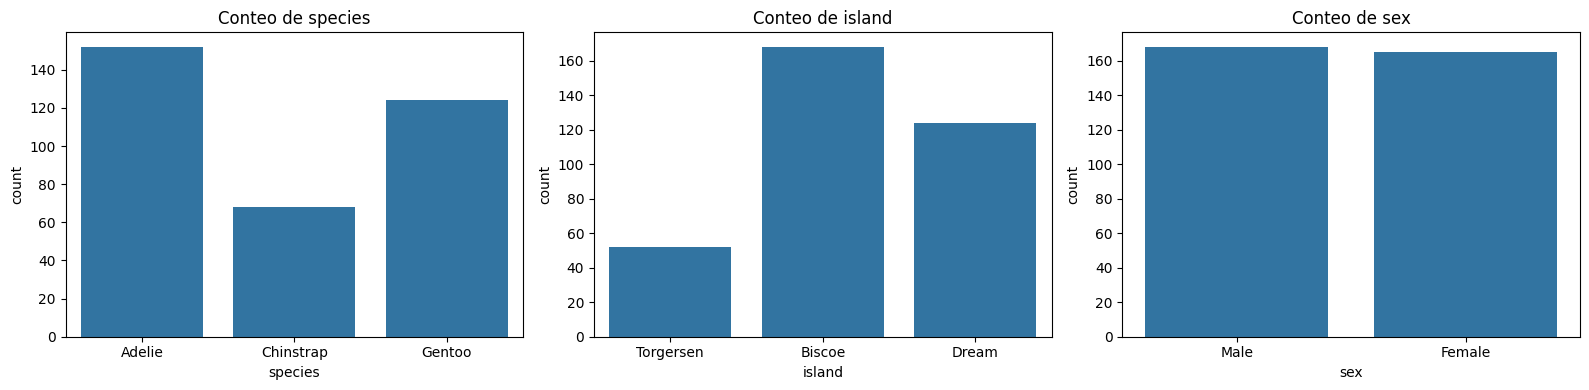

In [24]:
# 10) Gráficos de conteo para variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ["species", "island", "sex"]):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Conteo de {col}")
plt.tight_layout()
plt.show()

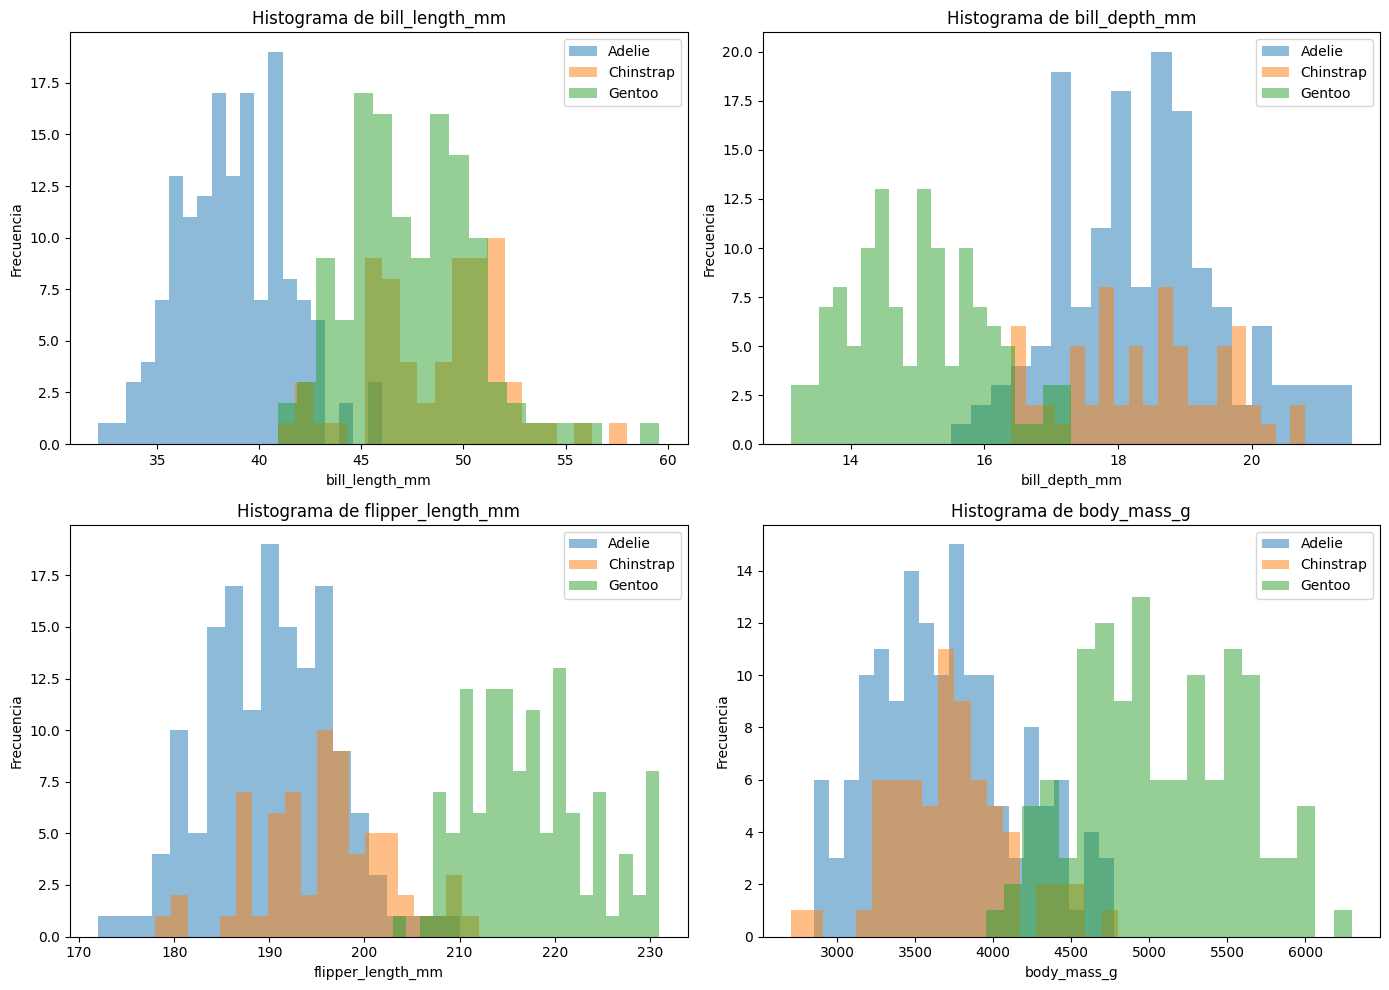

In [25]:
# 11) Histogramas de variables numéricas por especie
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), num_cols):
    for sp, grp in df.groupby("species"):
        ax.hist(grp[col].dropna(), alpha=0.5, label=sp, bins=20)
    ax.set_title(f"Histograma de {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frecuencia")
    ax.legend()
plt.tight_layout()
plt.show()

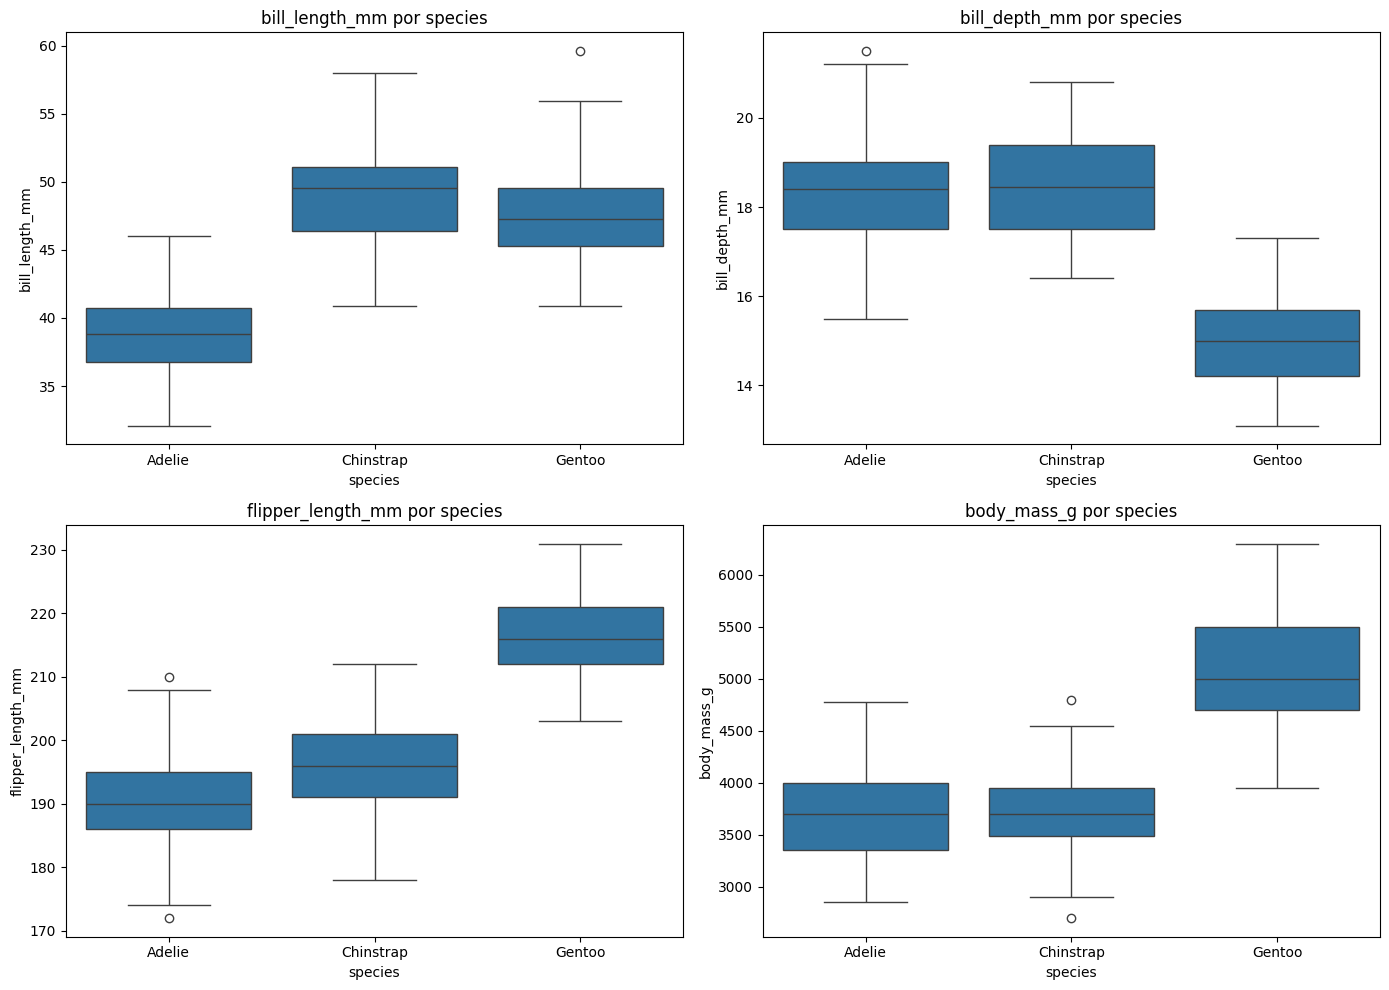

In [26]:
# 12) Boxplots de variables numéricas por species
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col in zip(axes.ravel(), num_cols):
    sns.boxplot(data=df, x="species", y=col, ax=ax)
    ax.set_title(f"{col} por species")
plt.tight_layout()
plt.show()

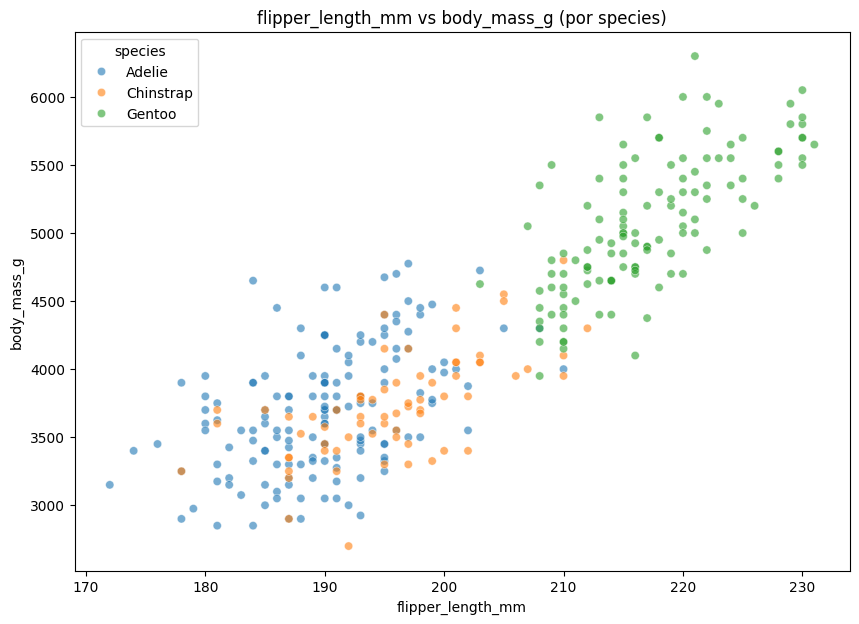

In [27]:
# 13) Scatter entre dos variables numéricas, coloreado por species
fig, ax = plt.subplots(figsize=(10, 7))
sns.scatterplot(data=df, x="flipper_length_mm", y="body_mass_g",
                hue="species", alpha=0.6, ax=ax)
ax.set_title("flipper_length_mm vs body_mass_g (por species)")
plt.show()

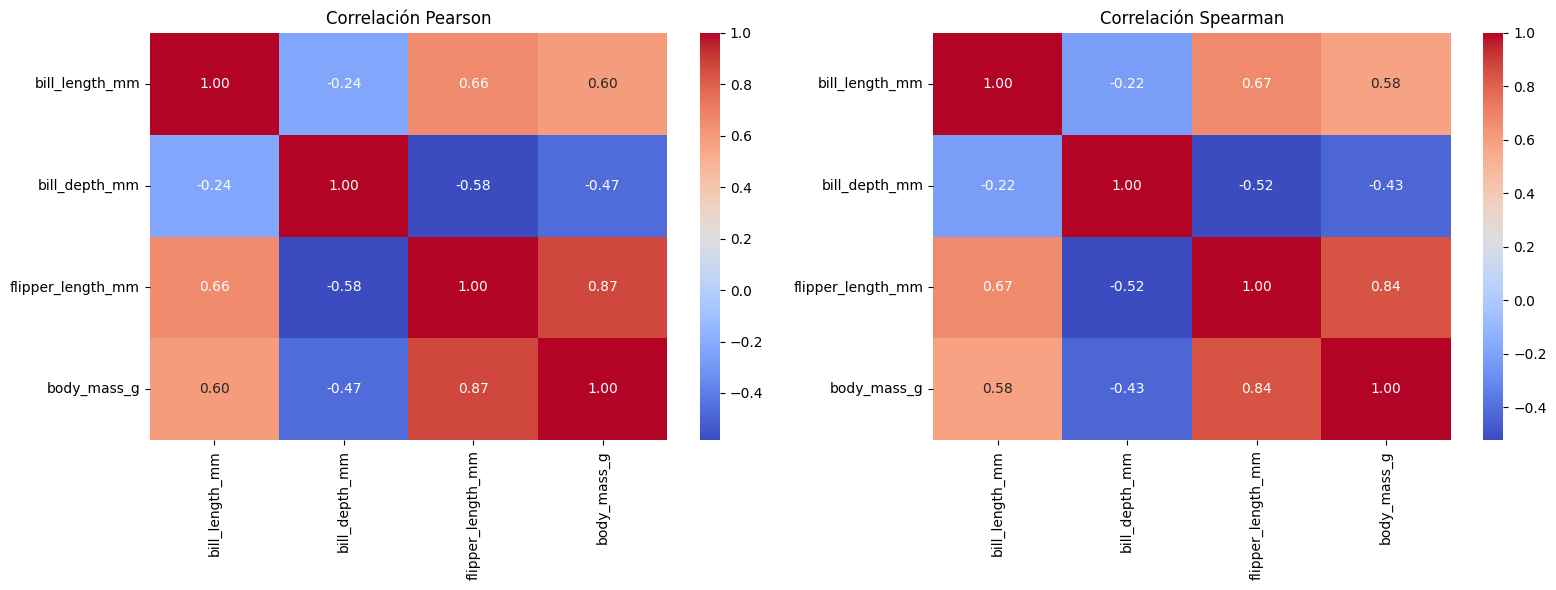

In [28]:
# 14) Heatmap de correlación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(corr_pearson, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0])
axes[0].set_title("Correlación Pearson")
sns.heatmap(corr_spearman, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1])
axes[1].set_title("Correlación Spearman")
plt.tight_layout()
plt.show()

## Parte D — Hipótesis (sin causalidad)

Con base en las descripciones y gráficos anteriores, se proponen las siguientes hipótesis:

**H1:** `flipper_length_mm` se asocia positivamente con `body_mass_g`.
- Evidencia: El scatter muestra una tendencia positiva clara; Pearson > 0.8.

**H2:** `bill_length_mm` difiere significativamente entre `species`.
- Evidencia: Los histogramas y boxplots muestran distribuciones diferenciadas por especie.

**H3:** La distribución de `species` se asocia con `island`.
- Evidencia: La tabla cruzada muestra que Chinstrap solo aparece en Dream, y Gentoo solo en Biscoe.

**H4:** `body_mass_g` difiere entre sexos (Male vs Female).
- Evidencia: Se espera dimorfismo sexual en masa corporal.

## Parte E — Pruebas estadísticas

In [29]:
# 16-18) Pruebas estadísticas para cada hipótesis

# H1: Correlación flipper_length_mm vs body_mass_g
clean = df[["flipper_length_mm", "body_mass_g"]].dropna()
r_pearson, p_pearson = stats.pearsonr(clean["flipper_length_mm"], clean["body_mass_g"])
r_spearman, p_spearman = stats.spearmanr(clean["flipper_length_mm"], clean["body_mass_g"])
print("=== H1: flipper_length_mm ~ body_mass_g ===")
print(f"  Pearson r = {r_pearson:.4f}, p = {p_pearson:.2e}")
print(f"  Spearman r = {r_spearman:.4f}, p = {p_spearman:.2e}")
print(f"  → {'Apoya' if p_pearson < 0.05 else 'No apoya'} la hipótesis (α=0.05)")
print()

# H2: bill_length_mm difiere por species (Kruskal-Wallis)
groups_h2 = [g["bill_length_mm"].dropna().values for _, g in df.groupby("species")]
stat_kw, p_kw = stats.kruskal(*groups_h2)
print("=== H2: bill_length_mm difiere por species ===")
print(f"  Kruskal-Wallis H = {stat_kw:.4f}, p = {p_kw:.2e}")
print(f"  → {'Apoya' if p_kw < 0.05 else 'No apoya'} la hipótesis (α=0.05)")
print()

# H3: species se asocia con island (Chi-cuadrado)
ct = pd.crosstab(df["species"], df["island"])
chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
print("=== H3: species ~ island ===")
print(f"  Chi² = {chi2:.4f}, dof = {dof}, p = {p_chi:.2e}")
print(f"  → {'Apoya' if p_chi < 0.05 else 'No apoya'} la hipótesis (α=0.05)")
print()

# H4: body_mass_g difiere por sex (Mann-Whitney U)
male = df[df["sex"] == "Male"]["body_mass_g"].dropna()
female = df[df["sex"] == "Female"]["body_mass_g"].dropna()
stat_mw, p_mw = stats.mannwhitneyu(male, female, alternative="two-sided")
print("=== H4: body_mass_g difiere por sex ===")
print(f"  Mann-Whitney U = {stat_mw:.4f}, p = {p_mw:.2e}")
print(f"  → {'Apoya' if p_mw < 0.05 else 'No apoya'} la hipótesis (α=0.05)")

=== H1: flipper_length_mm ~ body_mass_g ===
  Pearson r = 0.8712, p = 4.37e-107
  Spearman r = 0.8400, p = 2.76e-92
  → Apoya la hipótesis (α=0.05)

=== H2: bill_length_mm difiere por species ===
  Kruskal-Wallis H = 244.1367, p = 9.69e-54
  → Apoya la hipótesis (α=0.05)

=== H3: species ~ island ===
  Chi² = 299.5503, dof = 4, p = 1.35e-63
  → Apoya la hipótesis (α=0.05)

=== H4: body_mass_g difiere por sex ===
  Mann-Whitney U = 20845.5000, p = 1.81e-15
  → Apoya la hipótesis (α=0.05)


## Parte F — Conclusiones y reporte

### A) Hallazgos descriptivos
- El dataset contiene 344 observaciones de 3 especies (Adelie, Chinstrap, Gentoo) en 3 islas (Biscoe, Dream, Torgersen).
- Existen valores faltantes en `sex` y en las 4 variables de medición corporal.
- `body_mass_g` presenta la mayor varianza entre las variables numéricas; `bill_depth_mm` la menor.
- Adelie es la especie más frecuente (152 registros), Chinstrap la menos (68).

### B) Patrones visuales
- Los histogramas de `bill_length_mm` muestran distribuciones bimodales que se separan claramente por especie, con Adelie presentando picos más bajos.
- El scatter `flipper_length_mm` vs `body_mass_g` muestra clusters diferenciados por especie con una tendencia lineal positiva en cada grupo.
- Los boxplots revelan que Gentoo tiene las mayores aletas y masa corporal, mientras que Adelie y Chinstrap son más compactos.

### C) Próximas hipótesis
- Investigar si `bill_depth_mm` difiere por species controlando por `sex`.
- Analizar si la relación `flipper_length_mm` - `body_mass_g` varía por `island`.
- Evaluar la interacción entre `species` y `sex` en las medidas morfológicas.

### Preguntas para el investigador
1. ¿Cómo deben tratarse los valores faltantes en `sex`? ¿Eliminar filas o imputar?
2. ¿Se debería controlar el análisis por `species` al comparar sexos (dado el efecto confusor)?
3. ¿Existe un factor temporal (año de recolección) que pueda afectar las mediciones?

# FASE 2 — Enfoque con Agentes

En esta fase se usa la arquitectura **Agente + Runner**:
- **Runner** (`runner.py`): Ejecuta operaciones, calcula estadísticas, genera gráficos y escribe artifacts (JSON/PNG).
- **Agente** (prompt `hola_agentes.txt`): Planifica operaciones e interpreta resultados basándose únicamente en los artifacts.

El flujo es cíclico por fases: OBSERVE → DESCRIBE → HYPOTHESIZE_AND_CONCLUDE.

## Ejecución del Runner

In [30]:
import subprocess, os, sys

runner_dir = os.path.dirname(os.path.abspath("__file__"))
runner_path = os.path.join(runner_dir, "runner.py")

# Ejecutar las 3 fases secuencialmente (usando el mismo intérprete del kernel)
for phase in ["OBSERVE", "DESCRIBE", "HYPOTHESIZE_AND_CONCLUDE"]:
    print(f"\n{'='*60}")
    print(f"Ejecutando fase: {phase}")
    print(f"{'='*60}")
    result = subprocess.run(
        [sys.executable, runner_path, "--phase", phase],
        capture_output=True, text=True, cwd=runner_dir
    )
    print(result.stdout)
    if result.stderr:
        print("STDERR:", result.stderr[:500])


Ejecutando fase: OBSERVE
Dataset cargado desde seaborn: (344, 7)

=== FASE OBSERVE ===
  [artifact] C:\Users\jhjurad\computacional_2\002_EstudiantesAprendizajeEstadistico\semestre2026-1\Estudiantes\Jurado_90\artifacts\00_raw_profile.json

âœ“ Fase completada.


Ejecutando fase: DESCRIBE
Dataset cargado desde seaborn: (344, 7)

=== FASE DESCRIBE ===
  [artifact] C:\Users\jhjurad\computacional_2\002_EstudiantesAprendizajeEstadistico\semestre2026-1\Estudiantes\Jurado_90\artifacts\04_descriptive_stats.json
  [artifact] C:\Users\jhjurad\computacional_2\002_EstudiantesAprendizajeEstadistico\semestre2026-1\Estudiantes\Jurado_90\artifacts\05_visual_registry.json

âœ“ Fase completada.

STDERR: c:\Users\jhjurad\computacional_2\002_EstudiantesAprendizajeEstadistico\semestre2026-1\Estudiantes\Jurado_90\runner.py:159: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future v

In [31]:
# Verificar artifacts generados
import json
from pathlib import Path

artifacts_dir = Path(runner_dir) / "artifacts"

print("=== Artifacts generados ===\n")
for f in sorted(artifacts_dir.glob("*.json")):
    size = f.stat().st_size
    print(f"  {f.name} ({size:,} bytes)")

print(f"\n=== Gráficos generados ===\n")
plots_dir = artifacts_dir / "plots"
if plots_dir.exists():
    for f in sorted(plots_dir.glob("*.png")):
        print(f"  {f.name}")

# Mostrar contenido del perfil
print("\n=== Contenido de 00_raw_profile.json ===\n")
with open(artifacts_dir / "00_raw_profile.json", encoding="utf-8") as f:
    profile = json.load(f)
print(f"Filas: {profile['profile']['n_rows']}")
print(f"Columnas: {profile['profile']['n_cols']}")
print(f"Variables: {profile['profile']['columns']}")
print(f"\nFaltantes:")
for col, info in profile['missing'].items():
    if info['n_missing'] > 0:
        print(f"  {col}: {info['n_missing']} ({info['pct_missing']}%)")

=== Artifacts generados ===

  00_raw_profile.json (2,705 bytes)
  04_descriptive_stats.json (4,488 bytes)
  05_visual_registry.json (3,050 bytes)
  06_hypotheses_log.json (2,141 bytes)
  07_conclusions.json (1,403 bytes)
  08_tests.json (1,009 bytes)
  09_questions.json (314 bytes)

=== Gráficos generados ===

  box_bill_length_mm_by_species.png
  box_body_mass_g_by_species.png
  box_flipper_length_mm_by_species.png
  count_island.png
  count_island_by_species.png
  count_sex.png
  count_sex_by_species.png
  count_species.png
  heatmap_corr_pearson.png
  heatmap_corr_spearman.png
  hist_bill_depth_mm_by_species.png
  hist_bill_length_mm_by_species.png
  hist_body_mass_g_by_species.png
  hist_flipper_length_mm_by_species.png
  scatter_body_mass_g_vs_flipper_length_mm_hue_species.png

=== Contenido de 00_raw_profile.json ===

Filas: 344
Columnas: 7
Variables: ['species', 'island', 'bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'sex']

Faltantes:
  bill_length_mm:

In [32]:
# Mostrar resultados de las pruebas estadísticas (generadas por el runner)
with open(artifacts_dir / "08_tests.json", encoding="utf-8") as f:
    tests = json.load(f)

print("=== Pruebas estadísticas (del Runner) ===\n")
for t in tests["tests"]:
    result = "Apoya" if t["supports_hypothesis"] else "No apoya"
    print(f"{t['hypothesis_id']} — {t['test']}:")
    print(f"  Estadístico: {t['statistic']}, p-valor: {t['p_value']:.2e}")
    print(f"  → {result} la hipótesis (α=0.05)")
    print()

=== Pruebas estadísticas (del Runner) ===

H1 — pearson_correlation:
  Estadístico: 0.8712, p-valor: 4.37e-107
  → Apoya la hipótesis (α=0.05)

H1 — spearman_correlation:
  Estadístico: 0.84, p-valor: 2.76e-92
  → Apoya la hipótesis (α=0.05)

H2 — kruskal_wallis:
  Estadístico: 244.1367, p-valor: 9.69e-54
  → Apoya la hipótesis (α=0.05)

H3 — chi_squared:
  Estadístico: 299.5503, p-valor: 1.35e-63
  → Apoya la hipótesis (α=0.05)

H4 — mann_whitney_u:
  Estadístico: 20845.5, p-valor: 1.81e-15
  → Apoya la hipótesis (α=0.05)




--- box_bill_length_mm_by_species.png ---


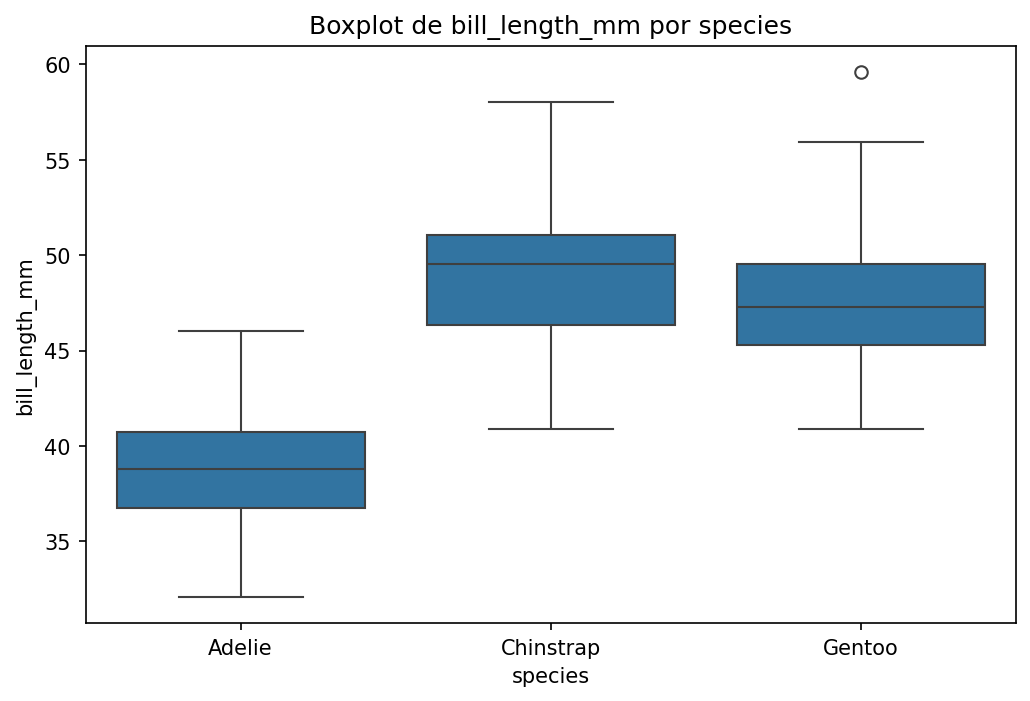


--- box_body_mass_g_by_species.png ---


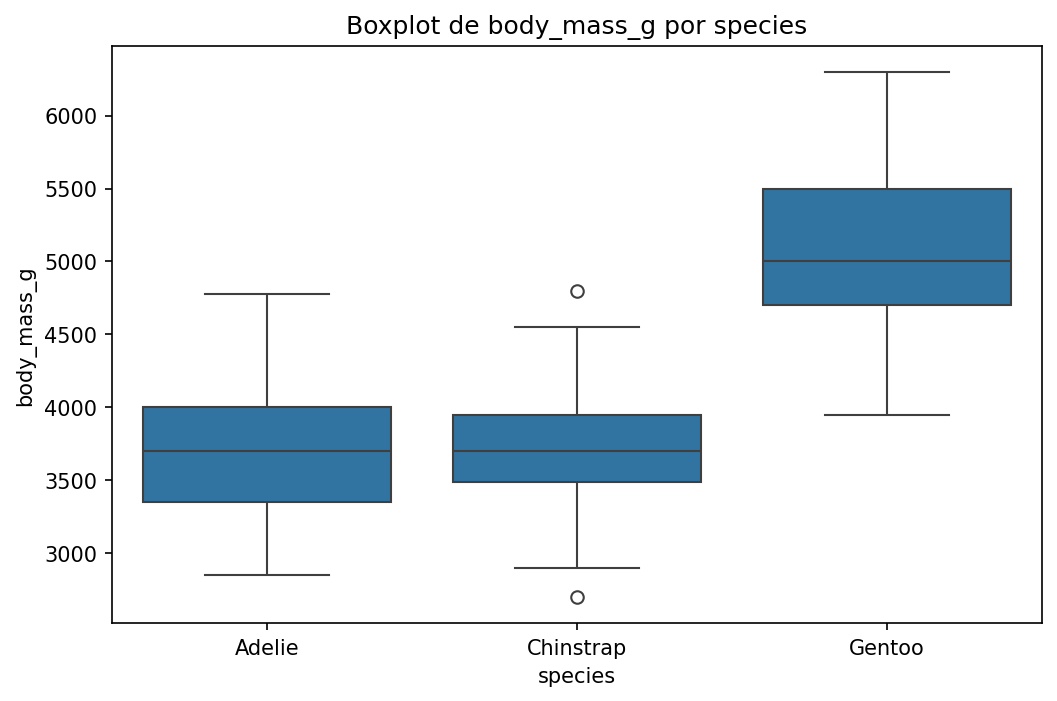


--- box_flipper_length_mm_by_species.png ---


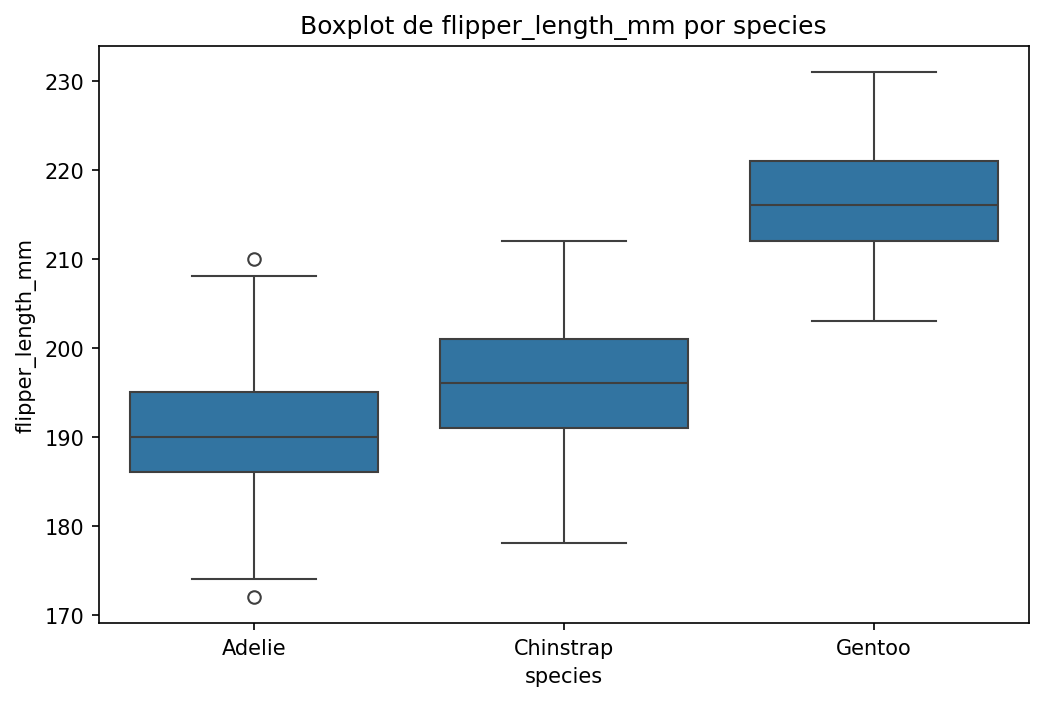


--- count_island.png ---


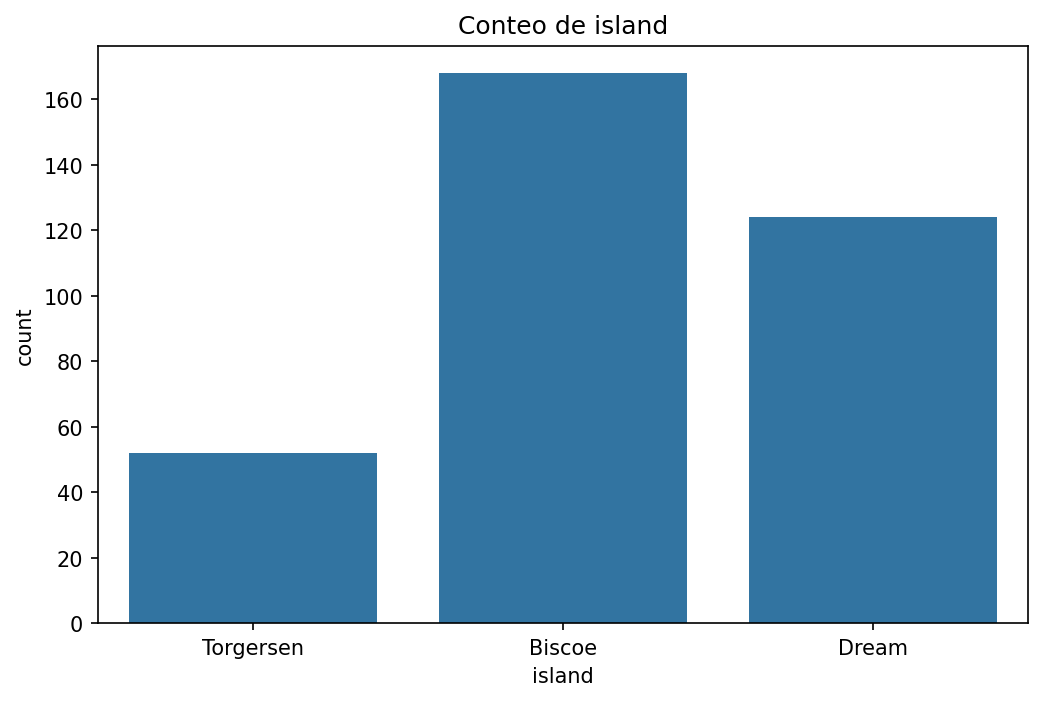


--- count_island_by_species.png ---


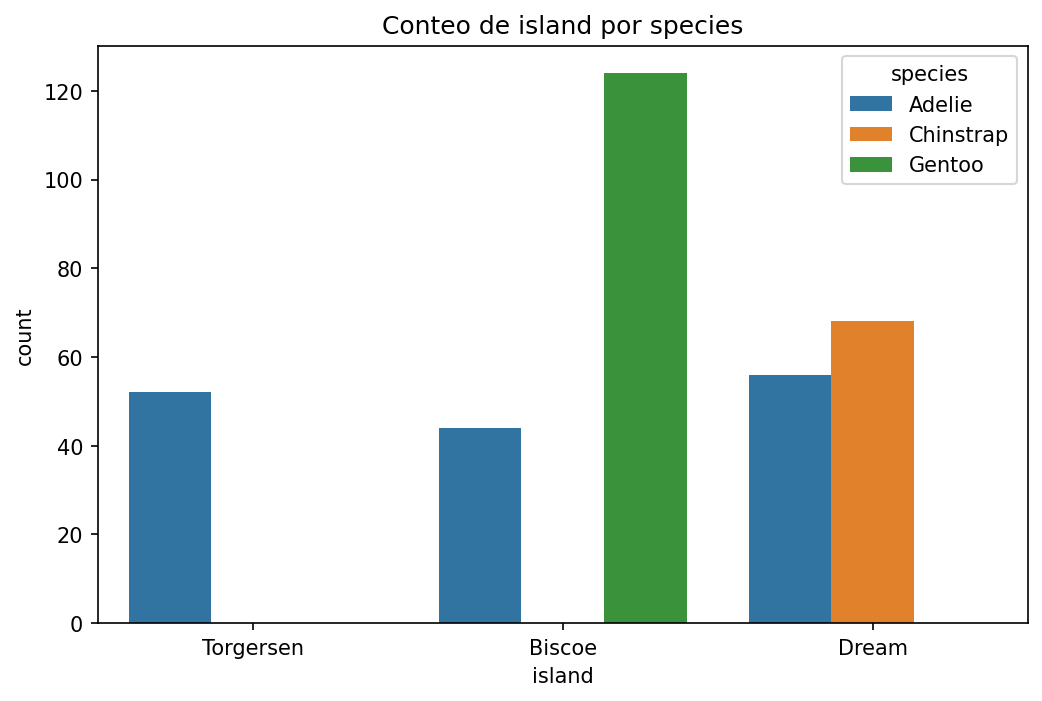


--- count_sex.png ---


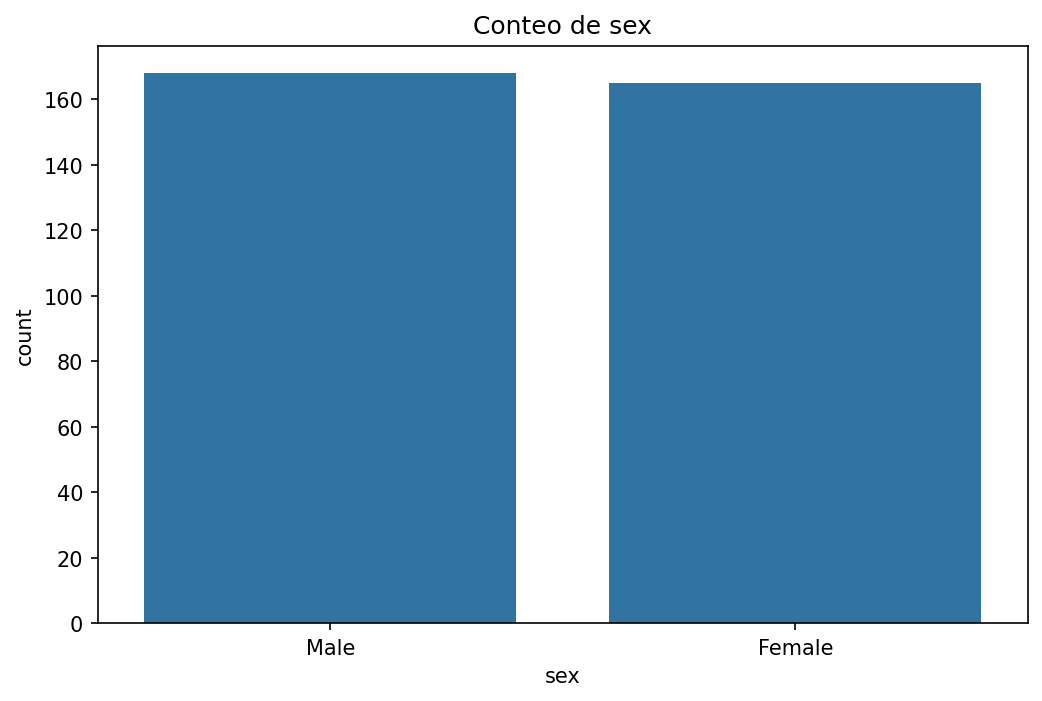

In [33]:
# Mostrar algunos gráficos generados por el runner
from IPython.display import Image, display

plots_dir = artifacts_dir / "plots"
plot_files = sorted(plots_dir.glob("*.png"))

# Mostrar los primeros 6 gráficos
for pf in plot_files[:6]:
    print(f"\n--- {pf.name} ---")
    display(Image(filename=str(pf), width=600))

## Registro de interacción con el agente

### Fase OBSERVE
**Prompt al agente:** Se le indicó `phase=OBSERVE` sin artifacts disponibles.

**Respuesta del agente:** Solicitó ejecutar `profile_dataset`, `infer_schema`, `missing_report`, `duplicates_report`.

**Acción del runner:** Se ejecutó `python runner.py --phase OBSERVE`. Generó `artifacts/00_raw_profile.json`.

### Fase DESCRIBE
**Prompt al agente:** Se le indicó `phase=DESCRIBE` con el perfil disponible.

**Respuesta del agente:** Solicitó resúmenes numéricos/categóricos, correlaciones (Pearson y Spearman), y gráficos exploratorios seleccionados por varianza y cardinalidad.

**Acción del runner:** Se ejecutó `python runner.py --phase DESCRIBE`. Generó `artifacts/04_descriptive_stats.json`, `artifacts/05_visual_registry.json` y gráficos en `artifacts/plots/`.

### Fase HYPOTHESIZE_AND_CONCLUDE
**Prompt al agente:** Se le indicó `phase=HYPOTHESIZE_AND_CONCLUDE` con artifacts descriptivos.

**Respuesta del agente:** Formuló 4 hipótesis falsables (H1-H4), sugirió pruebas estadísticas, redactó conclusiones en 3 capas y planteó preguntas para el investigador.

**Acción del runner:** Se ejecutó `python runner.py --phase HYPOTHESIZE_AND_CONCLUDE`. Generó `06_hypotheses_log.json`, `07_conclusions.json`, `08_tests.json`, `09_questions.json` y `report.md`.

## Comparación: Enfoque clásico vs Agentes

| Aspecto | Clásico (notebook) | Agentes (runner) |
|---|---|---|
| **Reproducibilidad** | Depende del orden de ejecución de celdas | Determinista: `python runner.py --phase ALL` |
| **Trazabilidad** | Resultados inline en el notebook | Artifacts JSON con timestamps |
| **Anti-alucinación** | El analista puede inventar valores | El agente solo cita artifacts verificables |
| **Flexibilidad** | Exploración libre celda a celda | Fases estructuradas, menos improvisación |
| **Generalización** | Requiere reescribir el notebook | El runner se adapta a cualquier dataset |
| **Gráficos** | Selección manual | Selección adaptativa por varianza/correlación |